In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# Kullanılacak 3 Model
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
# Başarı Metrikleri (R2, RMSE, MAE)
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

print("✅ Kütüphaneler yüklendi.")

✅ Kütüphaneler yüklendi.


In [2]:
dosya_adi = 'housing.csv'

try:
    df = pd.read_csv(dosya_adi)
    print(f"✅ Veri başarıyla yüklendi. Boyut: {df.shape}")
    print("-" * 30)
    display(df.head())
except FileNotFoundError:
    print("❌ HATA: 'housing.csv' dosyası bulunamadı. Lütfen sol tarafa yüklediğinden emin ol.")

✅ Veri başarıyla yüklendi. Boyut: (20640, 10)
------------------------------


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
# 'total_bedrooms' boş olan yerleri ortalama ile dolduruyoruz
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].mean())

# 2. Kategorik Veriyi Sayıya Çevirme
# 'ocean_proximity' sütununu (NEAR BAY vs.) sayısal 1-0 haline getiriyoruz
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

# 3. X (Özellikler) ve y (Hedef) Belirleme
X = df.drop('median_house_value', axis=1)  # Fiyatı çıkar, gerisi özellik
y = df['median_house_value']               # Tahmin edilecek şey: Fiyat

# 4. Train - Test Ayrımı
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Ölçekleme (Standardization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Ön işleme tamamlandı.")
print(f"Eğitim verisi: {X_train.shape}")
print(f"Test verisi: {X_test.shape}")

✅ Ön işleme tamamlandı.
Eğitim verisi: (16512, 12)
Test verisi: (4128, 12)


In [4]:
# HÜCRE 4: Model Eğitimi ve Performans
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=50, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

results = []
print("🚀 Modeller eğitiliyor... (Random Forest 30-40 saniye sürebilir)\n")

for name, model in models.items():
    start_time = time.time()

    model.fit(X_train_scaled, y_train) # Eğit
    y_pred = model.predict(X_test_scaled) # Tahmin Et

    end_time = time.time()
    duration = end_time - start_time

    # Metrikler
    r2 = r2_score(y_test, y_pred)  # Başarı oranı (1'e ne kadar yakınsa o kadar iyi)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred)) # Hata payı (Düşük iyi)
    mae = mean_absolute_error(y_test, y_pred) # Ortalama mutlak hata

    print(f"✅ {name} Bitti. Süre: {duration:.2f} sn")
    print(f"   R2: {r2:.4f} | RMSE: {rmse:.0f}")
    print("-" * 40)

    results.append({
        "Model": name,
        "R2 Score": r2,
        "RMSE": rmse,
        "MAE": mae,
        "Time (s)": duration
    })

# Sonuç Tablosu
results_df = pd.DataFrame(results)
print("\n🏆 Performans Tablosu:")
display(results_df)

🚀 Modeller eğitiliyor... (Random Forest 30-40 saniye sürebilir)

✅ Linear Regression Bitti. Süre: 0.04 sn
   R2: 0.6257 | RMSE: 70031
----------------------------------------
✅ Random Forest Bitti. Süre: 10.93 sn
   R2: 0.8165 | RMSE: 49034
----------------------------------------
✅ Gradient Boosting Bitti. Süre: 4.29 sn
   R2: 0.7609 | RMSE: 55970
----------------------------------------

🏆 Performans Tablosu:


,Model,R2 Score,RMSE,MAE,Time (s)
0,Linear Regression,0.625735,70031.419920,50701.779031,0.038907
1,Random Forest,0.816517,49034.394551,31886.809230,10.928874
2,Gradient Boosting,0.760942,55969.935723,38357.783428,4.288136


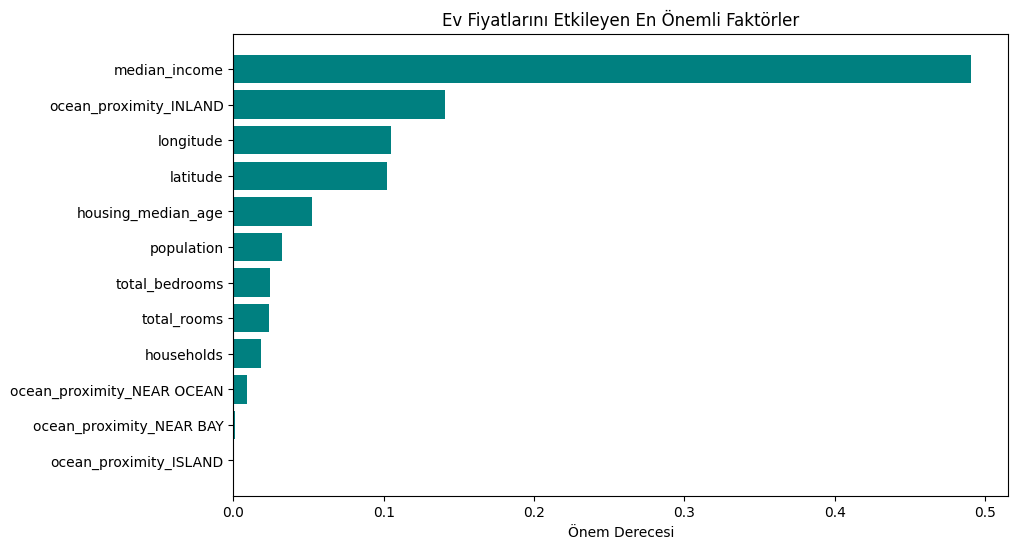

In [5]:
rf_model = models["Random Forest"] # En iyi modeli seçiyoruz
importances = rf_model.feature_importances_
feature_names = X.columns

# Grafiği çizdir
plt.figure(figsize=(10, 6))
indices = np.argsort(importances)[::-1] # Sırala
plt.barh(range(len(indices)), importances[indices], align='center', color='teal')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Önem Derecesi')
plt.title('Ev Fiyatlarını Etkileyen En Önemli Faktörler')
plt.gca().invert_yaxis() # En önemlisi en üstte olsun
plt.show()

In [6]:
import platform
try:
    import psutil
    ram = psutil.virtual_memory().total / (1024**3)
    print(f"RAM: {ram:.2f} GB")
except:
    print("RAM: Google Colab Standard (~12 GB)")

print(f"İşletim Sistemi: {platform.system()} {platform.release()}")
print(f"İşlemci: {platform.processor()}")
print("Not: Bu proje Google Colab bulut sunucularında çalıştırılmıştır.")

RAM: 12.67 GB
İşletim Sistemi: Linux 6.6.105+
İşlemci: x86_64
Not: Bu proje Google Colab bulut sunucularında çalıştırılmıştır.


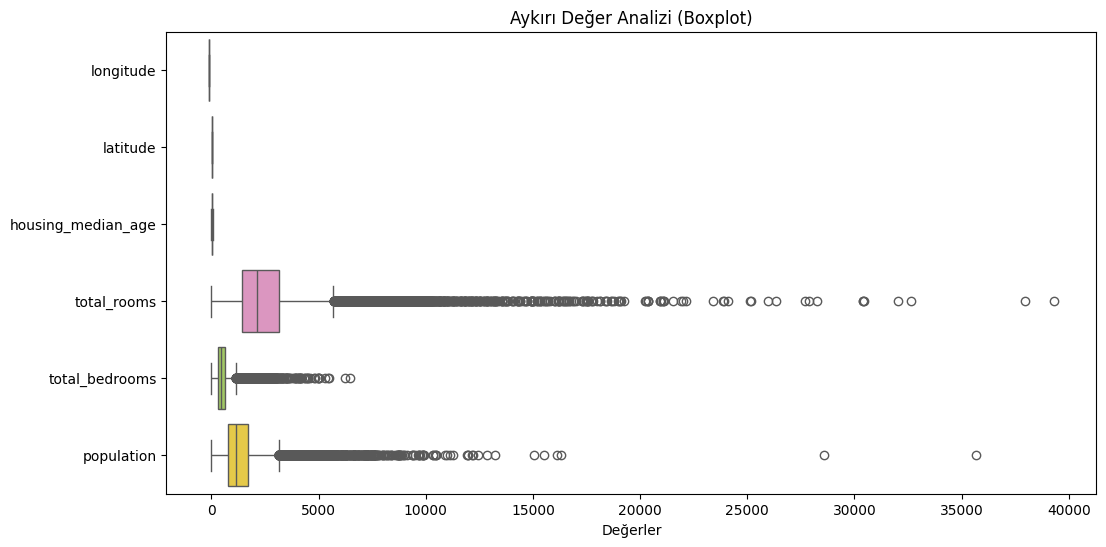

Yorum: Grafikteki kutuların sağında veya solunda tek başına duran noktalar 'Aykırı Değer'lerdir.


In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sadece sayısal sütunları seçelim
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Çok fazla sütun varsa grafiği sıkıştırmayalım, ilk 5-6 tanesine bakalım
cols_to_plot = numeric_cols[:6]

plt.figure(figsize=(12, 6))
sns.boxplot(data=df[cols_to_plot], orient='h', palette="Set2")
plt.title('Aykırı Değer Analizi (Boxplot)')
plt.xlabel('Değerler')
plt.show()

print("Yorum: Grafikteki kutuların sağında veya solunda tek başına duran noktalar 'Aykırı Değer'lerdir.")